In [1]:
import pandas as pd  # 导入 pandas，用于数据处理（Excel 表的操作）
import numpy as np    # 导入 numpy，用于数值计算（处理大型数组）
import matplotlib.pyplot as plt  # 导入绘图库，用于画图表
import seaborn as sns    # 导入更美观的绘图库，用于统计可视化
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold  # 从 sklearn 导入数据分割工具：把数据拆成“训练集”和“测试集”
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # 导入模型：随机森林分类器、梯度提升分类器（这两个是效果好的“集成学习”模型）
from sklearn.linear_model import LogisticRegression # 导入逻辑回归（经典的线性模型）
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report # 导入评估指标：AUC值、混淆矩阵、分类报告（用来判断模型分数高低）
from sklearn.preprocessing import StandardScaler # 导入数据预处理：标准化（让数据特征范围一致，提升模型效果）
from sklearn.calibration import calibration_curve # 导入校准曲线（调整模型概率预测的准确性）
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 设置中文显示和绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

print("=" * 80)
print("流失预警 + Uplift Model + 干预策略设计")
print("数据集：Hillstrom Marketing Dataset")
print("=" * 80)

流失预警 + Uplift Model + 干预策略设计
数据集：Hillstrom Marketing Dataset


In [1]:
import pandas as pd

# ============================================================
# 第一阶段：数据加载与探索性分析
# ============================================================

def load_and_explore_data(filepath):
    """加载数据并进行探索性分析"""
    
    print("\n" + "=" * 60)
    print("第一阶段：数据加载与探索性分析")
    print("=" * 60)
    
    # 加载数据
    df = pd.read_csv(filepath)
    print(f"\n✅ 数据加载成功！")
    print(f"   数据规模：{df.shape[0]} 行 x {df.shape[1]} 列")
    
    # 查看数据基本信息
    print("\n📊 数据字段：")
    print(df.columns.tolist())
    
    print("\n📊 数据类型：")
    print(df.dtypes)
    
    print("\n📊 缺失值检查：")
    print(df.isnull().sum())
    
    print("\n📊 数据统计描述：")
    print(df.describe())
    
    # 检查目标变量分布
    print(f"\n📊 目标变量(conversion)分布：")
    # 逻辑：conversion 列一般是0/1变量，1=转化，sum()就是所有转化用户的数量
    print(f"   转化用户数：{df['conversion'].sum()}")
       # 逻辑：1 - conversion 会把1变成0、0变成1，sum()就得到了未转化用户的数量
    print(f"   未转化用户数：{(1 - df['conversion']).sum()}")  
    # 计算并打印整体转化率（即转化用户占总用户的比例）
    # :.4f 是保留4位小数；乘以100:.2f% 是把比例转成百分比格式，更直观
    print(f"   转化率：{df['conversion'].mean():.4f} ({df['conversion'].mean()*100:.2f}%)")
    
    
    # 检查Treatment分布
    print(f"\n📊 Treatment(offer)分布：")
     # 统计 offer 列中每个分组的用户数量
    # 比如“优惠A”“优惠B”“无优惠”各自有多少用户
    offer_dist = df['offer'].value_counts()
    # 循环遍历每个干预分组，打印分组名称、用户数量和占比
    # count/len(df)*100:.1f% 是计算该分组用户占总用户的百分比，保留1位小数
    for offer, count in offer_dist.items():
        print(f"   {offer}: {count} ({count/len(df)*100:.1f}%)")
    
    # 各Treatment组的转化率
    print(f"\n📊 各Treatment组转化率：")
    for offer in df['offer'].unique(): # 遍历所有不同的干预分组（比如每个offer类型）
        conv_rate = df[df['offer'] == offer]['conversion'].mean() # 筛选出当前offer分组的所有用户，计算他们的平均转化率
        print(f"   {offer}: {conv_rate:.4f} ({conv_rate*100:.2f}%)") # 打印该分组的转化率，同时显示小数和百分比格式
    
    # 计算整体ATE（Average Treatment Effect）
    treated_mask = df['offer'] != 'No Offer'  # 定义“处理组”的筛选条件：所有接受了营销干预（不是“No Offer”）的用户
    control_mask = df['offer'] == 'No Offer'  # 定义“对照组”的筛选条件：没有接受任何营销干预的用户
    # 计算平均处理效应：处理组的平均转化率 - 对照组的平均转化率
    # 结果为正，说明营销干预整体上提升了转化率；为负则说明干预有反效果
    ate = df[treated_mask]['conversion'].mean() - df[control_mask]['conversion'].mean()
    print(f"\n📊 平均处理效应(ATE)：{ate:.4f} ({ate*100:.2f}个百分点)") # 打印ATE值，同时显示小数和百分比（百分点）格式，更易解读
    print(f"   → 营销干预平均能提升 {ate*100:.2f}% 的转化率") # 用一句话总结ATE的业务含义，方便报告中直接引用
    
    return df

# ====================== 正确路径 ======================
df = load_and_explore_data(r"D:\data\data.csv")


第一阶段：数据加载与探索性分析

✅ 数据加载成功！
   数据规模：64000 行 x 9 列

📊 数据字段：
['recency', 'history', 'used_discount', 'used_bogo', 'zip_code', 'is_referral', 'channel', 'offer', 'conversion']

📊 数据类型：
recency            int64
history          float64
used_discount      int64
used_bogo          int64
zip_code          object
is_referral        int64
channel           object
offer             object
conversion         int64
dtype: object

📊 缺失值检查：
recency          0
history          0
used_discount    0
used_bogo        0
zip_code         0
is_referral      0
channel          0
offer            0
conversion       0
dtype: int64

📊 数据统计描述：
            recency       history  used_discount     used_bogo   is_referral  \
count  64000.000000  64000.000000   64000.000000  64000.000000  64000.000000   
mean       5.763734    242.085656       0.551031      0.549719      0.502250   
std        3.507592    256.158608       0.497393      0.497526      0.499999   
min        1.000000     29.990000       0.000000      

In [3]:
# ============================================================
# 第二阶段：特征工程
# ============================================================
import numpy as np
def feature_engineering(df):
    """特征工程：创建新特征、编码类别变量"""
    
    print("\n" + "=" * 60)
    print("第二阶段：特征工程")
    print("=" * 60)
    
    # 复制数据避免修改原数据
    df_feat = df.copy()
    
    # 1. 数值特征变换
    # 目的：处理长尾分布、对齐指标方向，提升后续模型效果
    # ==============================================

    # --------------------------
    # 历史消费金额特征处理
    # 问题：消费金额通常呈“长尾分布”，少数用户金额极高，会影响模型稳定性
    # 方法：对数/平方根变换，压缩极端值，让分布更接近正态
    # --------------------------
    # 对历史消费金额做对数变换（处理长尾分布）
    # np.log1p(x) 等价于 ln(1+x)，避免金额为0时log报错
    df_feat['log_history'] = np.log1p(df_feat['history'])
    # 对历史消费金额做平方根变换（处理长尾分布）
    # np.sqrt(x) 即开平方，是比对数更温和的压缩方式
    df_feat['sqrt_history'] = np.sqrt(df_feat['history'])
    
    # 距离上次购买的反向指标（越近越好）
    # --------------------------
    # 最近购买间隔(Recency)特征处理
    # 问题：Recency值越大，代表用户越久没买，活跃度越低，是“负向指标”
    # 目标：1. 转换为“正向指标”（值越大越活跃）；2. 压缩长尾分布
    # --------------------------
    # 距离上次购买的反向指标（越近越好）
    # 逻辑：1/(间隔天数+1)，间隔越小，结果越大；+1是为了避免间隔为0时除以0报错
    df_feat['recency_inverse'] = 1 / (df_feat['recency'] + 1)
    # 对Recency做对数变换（处理长尾分布）
    # np.log1p(x) 同样避免了间隔为0时的报错，同时压缩了长期未购用户的极端值
    df_feat['recency_log'] = np.log1p(df_feat['recency'])
    
    # 2. 交互特征
    # 目的：通过特征组合，捕捉单一特征无法体现的复杂业务逻辑
    # 历史消费 × 是否用过折扣
    df_feat['history_discount_interaction'] = df_feat['history'] * df_feat['used_discount']
    # --------------------------
    # 历史消费 × 是否用过买一送一
    # 业务含义：衡量用户的“价格敏感度”，即高消费用户对折扣的依赖程度
    # 逻辑：历史消费金额 × 是否使用过折扣（0/1变量）
    # 当用户高消费且用过折扣时，这个值会更高，代表这类用户对价格敏感，折扣对他们影响更大
    # --------------------------
    df_feat['history_bogo_interaction'] = df_feat['history'] * df_feat['used_bogo']
    # --------------------------
    # 活跃度综合指标（recency低 + 历史消费高）
    # 业务含义：综合用户的“近期活跃度”和“历史消费能力”，衡量用户的整体价值
    # 逻辑：最近购买反向指标（越近购买值越高） × 对数化的历史消费金额（压缩长尾分布）
    # 两个值都高的用户，就是“近期活跃+消费能力强”的高价值用户，这个指标可以直接体现用户价值
    # --------------------------
    df_feat['active_value_score'] = df_feat['recency_inverse'] * df_feat['log_history']
    
    # ==============================================
    # 3. 分箱特征
    # 目的：将连续型数值（如天数、金额）划分为有业务意义的区间，降低模型对极端值的敏感度
    # ==============================================

    # --------------------------
    # 按 recency（最近一次购买间隔天数）分箱
    # 业务含义：将用户按“活跃度”划分为不同等级，方便后续做分层运营
    # 区间划分逻辑：
    #   0-3天：超活跃用户
    #   4-7天：活跃用户
    #   8-14天：一般活跃用户
    #   15-30天：低活跃用户
    #   30天以上：沉睡用户/流失风险高用户
    # --------------------------
    df_feat['recency_bin'] = pd.cut(df_feat['recency'], 
                                     bins=[0, 3, 7, 14, 30, 100], 
                                     labels=['0-3天', '4-7天', '8-14天', '15-30天', '30天以上'])
    
    # --------------------------
    # 按 history（历史消费金额）分箱
    # 目的：将用户按消费能力划分为不同等级，方便后续做分层运营和模型训练
    # 区间划分逻辑：
    #   0-100元：低消费用户
    #   100-300元：中低消费用户
    #   300-600元：中消费用户
    #   600-1000元：中高消费用户
    #   1000元以上：高消费用户
    # --------------------------
    df_feat['history_bin'] = pd.cut(df_feat['history'], 
                                     bins=[0, 100, 300, 600, 1000, 10000], 
                                     labels=['0-100', '100-300', '300-600', '600-1000', '1000以上'])
    
    # ==============================================
    # 4. 类别特征编码（One-Hot Encoding）
    # 目的：将文本型的类别特征（如地区、渠道）转换成模型能理解的数值格式
    # ==============================================

    # --------------------------
    # zip_code（地区编码）编码
    # 业务含义：用户所在的地区类型（如Urban、Suburban、Rural）
    # 方法：One-Hot编码，将每个地区类型转换成一个独立的0/1列
    # --------------------------
    # 1. 对zip_code列进行独热编码，生成哑变量
    # prefix='zip'：生成的新列名会以'zip_'开头，例如'zip_Urban'、'zip_Rural'
    zip_dummies = pd.get_dummies(df_feat['zip_code'], prefix='zip')
    # 2. 将编码后的哑变量，和原来的特征表合并在一起
    # axis=1：表示按列拼接，把新生成的哑变量列添加到df_feat中
    df_feat = pd.concat([df_feat, zip_dummies], axis=1)
    
    # channel编码
    # 业务含义：用户的购买渠道（如Phone、Web、Multichannel）
    # 方法：One-Hot编码，将每个渠道类型转换成一个独立的0/1列
    # --------------------------
    # 1. 对channel列进行独热编码，生成哑变量
    # prefix='channel'：生成的新列名会以'channel_'开头，例如'channel_Phone'、'channel_Web'
    channel_dummies = pd.get_dummies(df_feat['channel'], prefix='channel')
    # 2. 将编码后的哑变量，和原来的特征表合并在一起
    # axis=1：表示按列拼接，把新生成的哑变量列添加到df_feat中
    df_feat = pd.concat([df_feat, channel_dummies], axis=1)
    
    # ==============================================
    # 5. 创建Treatment变量（多种定义方式）
    # 目的：为后续Uplift模型/因果推断，构建不同粒度的“干预变量”，用于分析营销活动的效果
    # ==============================================

    # --------------------------
    # 方式1：是否接受任何干预（粗粒度）
    # 业务含义：用户是否参与了任意一种营销活动
    # 逻辑：只要offer不是“No Offer”，就标记为1（接受干预），否则为0（对照组）
    # --------------------------
    df_feat['treatment_any'] = (df_feat['offer'] != 'No Offer').astype(int)
    
    # --------------------------
    # 方式2：区分折扣和买一送一（细粒度）
    # 业务含义：区分用户参与的具体活动类型，方便对比不同营销手段的效果
    # 逻辑：分别生成两个0/1变量，标记用户是否参与了“折扣”或“买一送一”活动
    # --------------------------
    # 标记是否参与了折扣活动
    df_feat['treatment_discount'] = (df_feat['offer'] == 'Discount').astype(int)
    # 标记是否参与了买一送一活动
    df_feat['treatment_bogo'] = (df_feat['offer'] == 'Buy One Get One').astype(int)
    
    # ==============================================
    # 6. 创建流失风险指标（基于规则）
    # 目的：根据用户最近购买时间和历史消费金额，手动划分流失风险等级
    # ==============================================

    # 高流失风险：超过14天未购买，且历史消费金额低于100（低价值+低活跃度，最易流失）
    df_feat['churn_risk_high'] = ((df_feat['recency'] > 14) & (df_feat['history'] < 100)).astype(int)
    # 中流失风险：超过7天未购买但未超过14天，活跃度中等，存在一定流失风险
    df_feat['churn_risk_medium'] = ((df_feat['recency'] > 7) & (df_feat['recency'] <= 14)).astype(int)
    # 低流失风险：最近7天内有购买，活跃度高，流失风险低
    df_feat['churn_risk_low'] = (df_feat['recency'] <= 7).astype(int)
    
    # ==============================================
    # 特征工程完成统计
    # 目的：打印特征工程前后的维度变化，方便检查新增特征是否符合预期
    # ==============================================
    print(f"\n✅ 特征工程完成！")
    print(f"   原始特征数：{df.shape[1]}")  # 原始数据的列数
    print(f"   新增特征数：{df_feat.shape[1] - df.shape[1]}") # 新增的特征数量
    print(f"   总特征数：{df_feat.shape[1]}") # 特征工程后的总列数
    
    # 打印新增的特征
    new_features = [col for col in df_feat.columns if col not in df.columns]
    print(f"\n   新增特征：{new_features}")
    
    # 返回处理好的特征表，供后续模型使用
    return df_feat

# 执行特征工程：调用上面定义的函数，处理原始数据
df_feat = feature_engineering(df)


第二阶段：特征工程

✅ 特征工程完成！
   原始特征数：9
   新增特征数：21
   总特征数：30

   新增特征：['log_history', 'sqrt_history', 'recency_inverse', 'recency_log', 'history_discount_interaction', 'history_bogo_interaction', 'active_value_score', 'recency_bin', 'history_bin', 'zip_Rural', 'zip_Surburban', 'zip_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web', 'treatment_any', 'treatment_discount', 'treatment_bogo', 'churn_risk_high', 'churn_risk_medium', 'churn_risk_low']


In [5]:
# ============================================================
# 第三阶段：定义特征集和准备建模数据
# ============================================================
from sklearn.model_selection import train_test_split
def prepare_modeling_data(df_feat, treatment_type='any'):
    """准备建模数据：选择特征、划分训练测试集"""
    
    print("\n" + "=" * 60)
    print("第三阶段：准备建模数据")
    print("=" * 60)
    
    # --------------------------
    # 选择数值特征列
    # 这里列出了所有要用于建模的数值型特征，包括：
    # 1. 原始基础特征（recency、history、used_discount等）
    # 2. 特征工程生成的变换特征（log_history、recency_inverse等）
    # 3. 交互特征（history_discount_interaction等）
    # 4. 流失风险标签（churn_risk_high等）
    # --------------------------
    numeric_features = [
        'recency', 'history', 'used_discount', 'used_bogo', 'is_referral',
        'log_history', 'sqrt_history', 'recency_inverse', 'recency_log',
        'history_discount_interaction', 'history_bogo_interaction',
        'active_value_score', 'churn_risk_high', 'churn_risk_medium', 'churn_risk_low'
    ]
    # --------------------------
    # 类别编码列
    # 定义独热编码后的类别特征列表，包括用户地区（zip）和渠道（channel）
    # --------------------------
    categorical_features = [
        'zip_Rural', 'zip_Suburban', 'zip_Urban',
        'channel_Phone', 'channel_Web', 'channel_Multichannel'
    ]
    
    # --------------------------
    # 确保所有特征列都存在
    # 1. 合并数值特征和类别特征，得到完整的特征列表
    # 2. 筛选出实际存在于数据中的特征，避免因列名错误导致后续报错
    # --------------------------
    all_features = numeric_features + categorical_features
    available_features = [col for col in all_features if col in df_feat.columns]
    
    # --------------------------
    # 打印特征统计信息，方便核对
    # 输出最终可用的特征总数，以及数值特征和类别特征的数量
    # --------------------------
    print(f"\n✅ 选择的特征数：{len(available_features)}")
    print(f"   数值特征：{len([f for f in available_features if f in numeric_features])}")
    print(f"   类别特征：{len([f for f in available_features if f in categorical_features])}")
    
    # --------------------------
    # 构建模型输入矩阵X
    # 从数据中提取筛选后的特征列，并创建副本，避免修改原始数据
    # -------------------------
    X = df_feat[available_features].copy()
    
    # --------------------------
    # 选择Treatment列（干预变量）
    # 根据函数参数treatment_type，选择不同粒度的干预变量，用于后续Uplift模型
    # 'any'：是否接受任何干预（粗粒度）
    # 'discount'：是否接受折扣干预（细粒度）
    # 'bogo'：是否接受买一送一干预（细粒度）
    # --------------------------
    if treatment_type == 'any':
        t = df_feat['treatment_any'].values
    elif treatment_type == 'discount':
        t = df_feat['treatment_discount'].values
    else:
        t = df_feat['treatment_bogo'].values
    
    # --------------------------
    # 准备目标变量y
    # conversion（是否转化/购买），是模型要预测的结果
    # --------------------------
    y = df_feat['conversion'].values
    
    # --------------------------
    # 打印干预组和对照组的分布情况
    # 用于检查数据是否平衡，避免出现某一组样本过少的情况
    # --------------------------
    print(f"\n📊 Treatment分布：")
    print(f"   Treatment组：{t.sum()} ({t.sum()/len(t)*100:.1f}%)")
    print(f"   Control组：{(1-t).sum()} ({(1-t).sum()/len(t)*100:.1f}%)")
    
    # --------------------------
    # 划分训练集和测试集
    # 说明：理想情况下应按时间顺序划分，避免数据泄露
    # 由于数据没有时间戳，采用分层随机划分，保证正负样本比例一致
    # --------------------------
    X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
        X, y, t, test_size=0.3, random_state=42, stratify=y
    )

     # --------------------------
    # 打印数据集划分结果
    # 核对训练集和测试集的样本数量，确保划分正确
    # --------------------------
    print(f"\n📊 数据集划分：")
    print(f"   训练集：{len(X_train)} 样本")
    print(f"   测试集：{len(X_test)} 样本")
    
    # --------------------------
    # 检查数据泄露风险/数据偏移
    # 核心目的：验证训练集和测试集的分布是否一致，避免因划分不当导致模型评估虚高
    # 这里用转化率作为核心指标，检查正负样本比例是否稳定
    # --------------------------
    print(f"\n⚠️ 数据泄露检查：")
    
    # 计算训练集和测试集的转化率（y的均值，因为y是0/1变量）
    train_conv_rate = y_train.mean()
    test_conv_rate = y_test.mean()
    
    # 打印两个数据集的转化率，保留4位小数
    print(f"   训练集转化率：{train_conv_rate:.4f}")
    print(f"   测试集转化率：{test_conv_rate:.4f}")
    
    # 计算两者差异，如果差异过大，说明分层抽样或数据本身存在问题
    print(f"   差异：{abs(train_conv_rate - test_conv_rate):.4f} → {'⚠️ 注意可能存在数据偏移' if abs(train_conv_rate - test_conv_rate) > 0.01 else '✅ 分布一致'}")

    # --------------------------
    # 返回建模所需的全部数据
    # 函数执行完毕，返回划分好的训练/测试集数据，以及最终使用的特征列表
    # --------------------------
    return X_train, X_test, y_train, y_test, t_train, t_test, available_features

    # --------------------------
    # 调用建模数据准备函数
    # 传入特征工程后的数据集，选择干预类型为'any'（粗粒度，即“是否接受任何干预”）
    # 函数返回训练/测试集的特征、目标变量、干预变量，以及最终特征列表
    # --------------------------
X_train, X_test, y_train, y_test, t_train, t_test, features = prepare_modeling_data(df_feat, treatment_type='any')


第三阶段：准备建模数据

✅ 选择的特征数：20
   数值特征：15
   类别特征：5

📊 Treatment分布：
   Treatment组：42694 (66.7%)
   Control组：21306 (33.3%)

📊 数据集划分：
   训练集：44800 样本
   测试集：19200 样本

⚠️ 数据泄露检查：
   训练集转化率：0.1468
   测试集转化率：0.1468
   差异：0.0000 → ✅ 分布一致


In [8]:
# ============================================================
# 第四阶段：Uplift Model构建（Two-Model Approach）
# 目的：使用两模型法（Two-Model）计算用户干预提升效果（Uplift）
# ============================================================
# 导入所需库
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

class TwoModelUplift:
    """
    两模型Uplift Model
    模型1：用Treatment组数据，预测有干预时的转化概率
    模型2：用Control组数据，预测无干预时的转化概率
    Uplift = P(转化|干预) - P(转化|无干预)
    """
    
    def __init__(self, model_class=RandomForestClassifier, model_params=None):
        self.model_class = model_class
        
        # 如果用户没传入参数，使用预设的随机森林参数
        self.model_params = model_params if model_params else {
            'n_estimators': 100,       # 决策树数量
            'max_depth': 6,            # 树的最大深度，防止过拟合
            'min_samples_split': 50,   # 节点分裂所需的最小样本数
            'min_samples_leaf': 25,    # 叶子节点所需的最小样本数
            'random_state': 42,        # 固定随机种子，保证结果可复现
            'class_weight': 'balanced' # 处理样本不平衡，对少数类加权
        }
        
        # 初始化两个模型实例，后续训练时会赋值
        self.model_treated = None   # 干预组模型
        self.model_control = None   # 对照组模型
        
    def fit(self, X, y, treatment):
        """训练两个模型"""
        
        # --------------------------
        # 1. 根据干预变量，分离干预组和对照组数据
        # --------------------------
        # 干预组：接受过干预的用户（treatment=1）
        X_treated = X[treatment == 1]
        y_treated = y[treatment == 1]
        # 对照组：未接受干预的用户（treatment=0）
        X_control = X[treatment == 0]
        y_control = y[treatment == 0]
        
        # 打印两组数据的样本量和转化率，方便核对数据分布
        print(f"\n📊 训练数据分布：")
        print(f"   Treatment组：{len(X_treated)} 样本（转化率：{y_treated.mean():.4f}）")
        print(f"   Control组：{len(X_control)} 样本（转化率：{y_control.mean():.4f}）")
        
        # --------------------------
        # 2. 检测类别不平衡并提示
        # 如果转化率过低（<10%），说明数据中正负样本严重不平衡
        # 模型参数中已设置class_weight='balanced'，自动对少数类加权
        # --------------------------
        if y_treated.mean() < 0.1 or y_control.mean() < 0.1:
            print(f"   ⚠️ 检测到类别不平衡，已启用class_weight='balanced'")
        
        # --------------------------
        # 3. 训练模型1：干预组模型（预测有干预时的转化概率）
        # --------------------------
        self.model_treated = self.model_class(**self.model_params)
        self.model_treated.fit(X_treated, y_treated)
        
        # --------------------------
        # 4. 训练模型2：对照组模型（预测无干预时的转化概率）
        # --------------------------
        self.model_control = self.model_class(**self.model_params)
        self.model_control.fit(X_control, y_control)
        
        # --------------------------
        # 5. 评估模型表现（在训练集上）
        # 使用AUC作为分类模型的评估指标，只在样本数>10时评估，避免报错
        # --------------------------
        if len(X_treated) > 10:
            auc_treated = roc_auc_score(y_treated, self.model_treated.predict_proba(X_treated)[:, 1])
            print(f"\n✅ Treatment组模型 AUC：{auc_treated:.4f}")
        if len(X_control) > 10:
            auc_control = roc_auc_score(y_control, self.model_control.predict_proba(X_control)[:, 1])
            print(f"✅ Control组模型 AUC：{auc_control:.4f}")
        
        # 训练完成，返回模型自身
        return self
    
    def predict_uplift(self, X):
        """预测Uplift分数"""
        # 1. 用干预组模型预测：假设用户接受干预时的转化概率
        prob_treated = self.model_treated.predict_proba(X)[:, 1]
        # 2. 用对照组模型预测：假设用户不接受干预时的转化概率
        prob_control = self.model_control.predict_proba(X)[:, 1]
        # 3. 计算两者差值，即干预带来的额外转化提升（Uplift）
        uplift = prob_treated - prob_control
        
        # 返回Uplift分数，以及两个模型的预测概率（方便后续分析）
        return uplift, prob_treated, prob_control
    
    def predict_conversion(self, X, treatment_status):
        """
        给定treatment状态，预测转化概率
        修复：支持数组/Series输入，解决原代码报错问题
        """
        # 转换为numpy数组，支持向量化运算
        treatment_status = np.array(treatment_status)
           
        # 先预测两种情况下的转化概率
        prob_treated = self.model_treated.predict_proba(X)[:, 1]
        prob_control = self.model_control.predict_proba(X)[:, 1]
        
        # 根据每个样本的实际干预状态，返回对应的概率
        # 干预状态为1（接受干预）→ 返回干预组模型的预测概率
        # 干预状态为0（未接受干预）→ 返回对照组模型的预测概率
        return np.where(treatment_status == 1, prob_treated, prob_control)
    
    def get_feature_importance(self, feature_names):
        """获取特征重要性"""
        
        # 构建包含两组模型特征重要性的DataFrame
        importance_df = pd.DataFrame({
            'feature': feature_names * 2,  # 重复两次特征名（分别对应干预组和对照组）
            'importance': list(self.model_treated.feature_importances_) + list(self.model_control.feature_importances_),
            'model': ['Treatment组'] * len(feature_names) + ['Control组'] * len(feature_names)
        })
        
        # 按重要性降序排列，方便查看影响最大的特征
        return importance_df.sort_values('importance', ascending=False)

# ==================================================
# 第四阶段：Uplift Model训练与评估
# ==================================================
print("\n" + "=" * 60)
print("第四阶段：Uplift Model训练")
print("=" * 60)

# --------------------------
# 1. 初始化Uplift模型
# 使用TwoModelUplift类，传入随机森林分类器和预设超参数
# --------------------------
uplift_model = TwoModelUplift(
    model_class=RandomForestClassifier,
    model_params={
        'n_estimators': 100,      # 决策树数量
        'max_depth': 6,           # 树的最大深度，防止过拟合
        'min_samples_split': 50,  # 节点分裂所需的最小样本数
        'min_samples_leaf': 25,   # 叶子节点所需的最小样本数
        'random_state': 42,       # 固定随机种子，保证结果可复现
        'class_weight': 'balanced'# 处理样本不平衡，对少数类加权
    }
)

# --------------------------
# 2. 训练Uplift模型
# 传入训练集特征、目标变量和干预变量，模型会自动分成干预组/对照组训练
# --------------------------
uplift_model.fit(X_train, y_train, t_train)

# --------------------------
# 3. 在测试集上预测Uplift分数
# 得到每个用户的干预提升效果，以及两个模型的预测概率
# --------------------------
uplift_scores, prob_treated, prob_control = uplift_model.predict_uplift(X_test)

# --------------------------
# 4. 评估模型的整体预测能力
# 用AUC评估模型对转化的预测能力，而非直接评估Uplift效果
# --------------------------
# 根据测试集用户的实际干预状态，获取模型预测的转化概率
pred_probs = uplift_model.predict_conversion(X_test, t_test)
# 计算AUC分数
auc_score = roc_auc_score(y_test, pred_probs)

# 打印评估结果，并根据AUC给出提示
print(f"\n📊 整体模型预测能力：")
print(f"   AUC：{auc_score:.4f}")
print(f"   {'✅ 模型有较好的预测能力' if auc_score > 0.65 else '⚠️ 模型预测能力一般，可能需要进一步优化'}")


第四阶段：Uplift Model训练

📊 训练数据分布：
   Treatment组：29804 样本（转化率：0.1671）
   Control组：14996 样本（转化率：0.1065）

✅ Treatment组模型 AUC：0.6500
✅ Control组模型 AUC：0.7083

📊 整体模型预测能力：
   AUC：0.6220
   ⚠️ 模型预测能力一般，可能需要进一步优化



第五阶段：Uplift Model评估（Qini曲线）

📊 Qini评估结果：
   Qini系数：0.0000
   Qini曲线下面积：62711.23
   随机策略曲线下面积：140900.00
   完美策略曲线下面积：140900.00
   ⚠️ Uplift模型效果有限，需要进一步优化


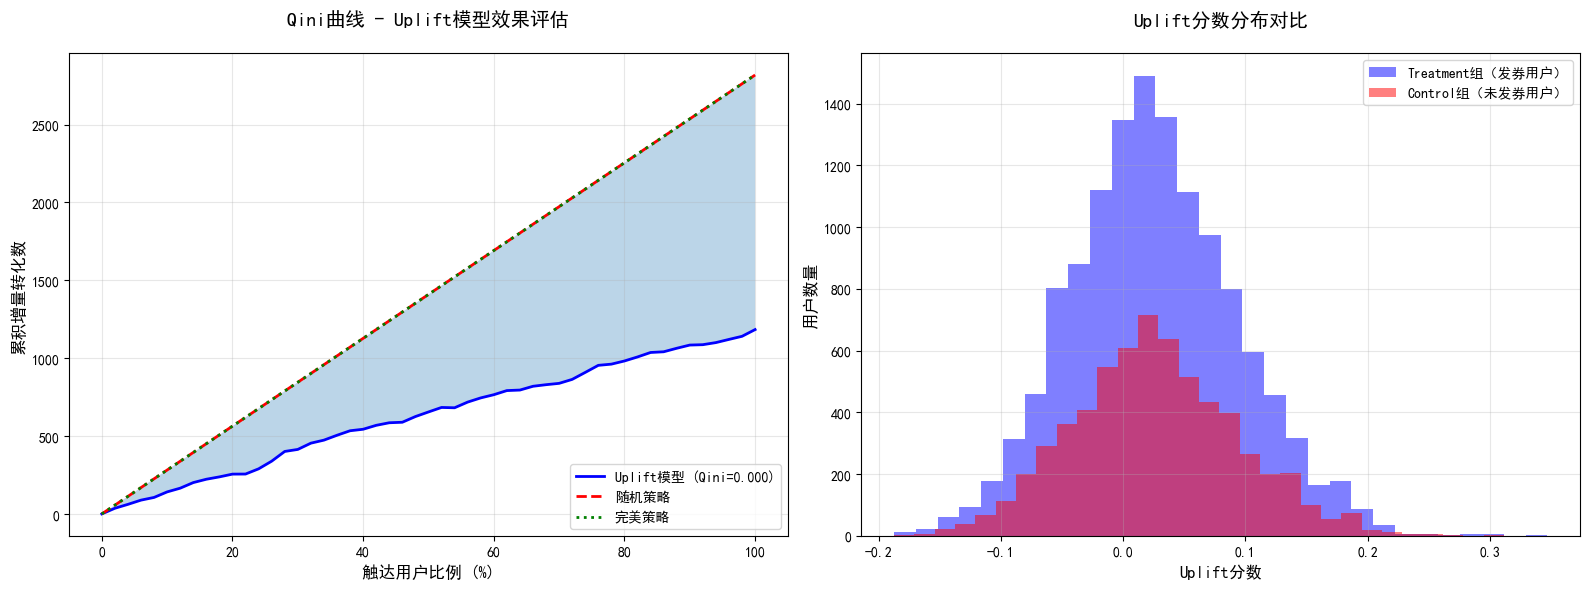

In [10]:
# ============================================================
# 第五阶段：Uplift Model评估（Qini曲线）
# 作用：专门评估Uplift模型好不好用，能不能精准找到“发券最有用”的用户
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置matplotlib中文显示，避免中文乱码、方框
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def qini_curve(y_true, treatment, uplift_scores, n_bins=50):
    """
    功能：计算Qini曲线数据（Uplift模型最核心的评估方法）
    参数说明：
        y_true: 真实转化结果（0=未购买，1=购买）
        treatment: 干预标记（0=没发券，1=发券）
        uplift_scores: 模型预测的Uplift分数（分数越高，发券越有用）
        n_bins: 将用户分成多少组来计算，默认50组
    返回：
        x轴: 用户百分比
        qini_values: 模型的Qini值
        random_qini: 随机选用户的Qini值（基线）
        perfect_qini: 完美模型的Qini值（理论上限）
    """
    # 1. 把真实结果、干预状态、预测分数拼成一张表
    df_eval = pd.DataFrame({
        'y': y_true,
        't': treatment,
        'uplift': uplift_scores
    })
    
    # 2. 按照模型预测的Uplift分数从高到低排序
    # 模型认为“发券越有用”的用户排在越前面
    df_eval = df_eval.sort_values('uplift', ascending=False).reset_index(drop=True)
    
    # 3. 计算总用户数，以及每一组有多少人
    n = len(df_eval)
    bin_size = max(1, n // n_bins)
    
    # 4. 初始化三条曲线的初始值（从0开始）
    qini_values = [0]
    random_qini = [0]
    perfect_qini = [0]
    
    # 5. 计算整体平均转化率（随机策略的参考值）
    global_conversion = y_true.mean()
    max_uplift = df_eval['y'].mean()  # 完美模型的理论上限
    
    # 6. 逐组累计计算Qini值
    for i in range(1, n_bins + 1):
        # 取到当前组的最后一个人
        end_idx = min(i * bin_size, n)
        # 取出“排名前N的用户”（模型认为最值得发券的人）
        current_bin = df_eval.iloc[:end_idx]
        
        # 区分：发券的人 / 没发券的人
        treated_mask = current_bin['t'] == 1
        control_mask = current_bin['t'] == 0
        
        # 计算：发券的人转化率 - 没发券的人转化率 = 真实提升效果
        if treated_mask.sum() > 0 and control_mask.sum() > 0:
            treated_conversion = current_bin.loc[treated_mask, 'y'].mean()
            control_conversion = current_bin.loc[control_mask, 'y'].mean()
            actual_uplift = treated_conversion - control_conversion
        else:
            actual_uplift = 0
        
        # 模型Qini = 累计人数 × 实际提升效果
        qini_values.append(end_idx * actual_uplift)
        # 随机选用户的Qini（作为对比底线）
        random_qini.append(end_idx * global_conversion)
        # 完美模型的Qini（作为天花板）
        perfect_qini.append(end_idx * max_uplift)
    
    # 把X轴变成0~100%
    x_axis = np.linspace(0, 100, n_bins + 1)
    
    return x_axis, np.array(qini_values), np.array(random_qini), np.array(perfect_qini)


def qini_coefficient(y_true, treatment, uplift_scores):
    """
    功能：计算Qini系数（Uplift模型的最终打分）
    分数越高 → 模型越能精准找到高价值用户
    大于0.1就说明模型有效
    """
    # 调用上面函数，拿到三条曲线的数据
    x, qini, random_qini, perfect_qini = qini_curve(y_true, treatment, uplift_scores)
    
    # 计算三条曲线下的面积（面积越大效果越好）
    qini_auc = np.trapz(qini, x)
    random_auc = np.trapz(random_qini, x)
    perfect_auc = np.trapz(perfect_qini, x)
    
    # 计算标准化Qini系数（0~1之间）
    if perfect_auc - random_auc > 0:
        qini_coef = (qini_auc - random_auc) / (perfect_auc - random_auc)
    else:
        qini_coef = 0
    
    return qini_coef, qini_auc, random_auc, perfect_auc


# ===================== 正式执行评估 =====================
print("\n" + "=" * 60)
print("第五阶段：Uplift Model评估（Qini曲线）")
print("=" * 60)

# 1. 计算Qini曲线
x_axis, qini_values, random_qini, perfect_qini = qini_curve(y_test, t_test, uplift_scores)

# 2. 计算Qini系数（模型得分）
qini_coef, qini_auc, random_auc, perfect_auc = qini_coefficient(y_test, t_test, uplift_scores)

# 3. 打印评估结果
print(f"\n📊 Qini评估结果：")
print(f"   Qini系数：{qini_coef:.4f}")
print(f"   Qini曲线下面积：{qini_auc:.2f}")
print(f"   随机策略曲线下面积：{random_auc:.2f}")
print(f"   完美策略曲线下面积：{perfect_auc:.2f}")
print(f"   {'✅ Uplift模型有效，能够有效识别高响应用户' if qini_coef > 0.1 else '⚠️ Uplift模型效果有限，需要进一步优化'}")

# ===================== 画图展示 =====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：Qini曲线（看模型比随机好多少）
ax1 = axes[0]
ax1.plot(x_axis, qini_values, 'b-', linewidth=2, label=f'Uplift模型 (Qini={qini_coef:.3f})')
ax1.plot(x_axis, random_qini, 'r--', linewidth=2, label='随机策略')
ax1.plot(x_axis, perfect_qini, 'g:', linewidth=2, label='完美策略')
ax1.fill_between(x_axis, random_qini, qini_values, alpha=0.3)
ax1.set_xlabel('触达用户比例 (%)', fontsize=12)
ax1.set_ylabel('累积增量转化数', fontsize=12)
ax1.set_title('Qini曲线 - Uplift模型效果评估', fontsize=14, pad=20)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# 右图：Uplift分数分布（看模型能不能区分两类用户）
ax2 = axes[1]
ax2.hist(uplift_scores[t_test == 1], bins=30, alpha=0.5, label='Treatment组（发券用户）', color='blue')
ax2.hist(uplift_scores[t_test == 0], bins=30, alpha=0.5, label='Control组（未发券用户）', color='red')
ax2.set_xlabel('Uplift分数', fontsize=12)
ax2.set_ylabel('用户数量', fontsize=12)
ax2.set_title('Uplift分数分布对比', fontsize=14, pad=20)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 自动调整布局，防止标题被截断
plt.tight_layout()

# 保存图片
plt.savefig('qini_curve_and_uplift_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


第六阶段：策略对比分析

📊 策略对比结果（不同触达比例下的转化率提升）：
   top_pct  n_users  random_effect  churn_effect  conv_effect  uplift_effect
0     0.05      960         0.0351        0.0069       0.0917         0.0724
1     0.10     1920         0.0532        0.0155       0.0852         0.0738
2     0.15     2880         0.0716        0.0323       0.0845         0.0733
3     0.20     3840         0.0639        0.0304       0.0651         0.0665
4     0.25     4800         0.0570        0.0382       0.0676         0.0656
5     0.30     5760         0.0571        0.0458       0.0641         0.0719
6     0.40     7680         0.0584        0.0480       0.0644         0.0708
7     0.50     9600         0.0517        0.0506       0.0648         0.0682


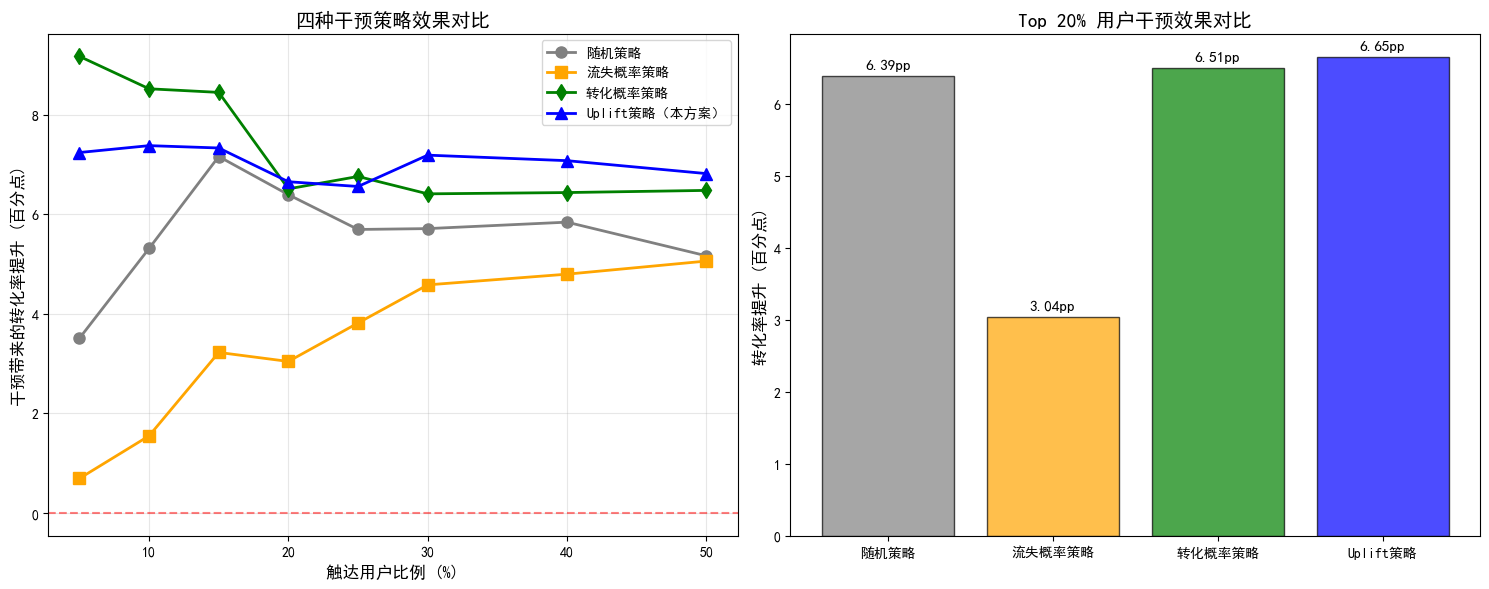

In [11]:
# ============================================================
# 第六阶段：策略对比
# 作用：对比 4 种营销发券策略，证明 Uplift 模型最好用
# 四种策略：随机选、按流失、按转化、按 Uplift
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示（防止图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def compare_strategies(y_test, t_test, uplift_scores, prob_churn=None):
    """
    功能：对比 4 种干预（发券）策略，看哪种效果最好
    4 种策略：
        1. 随机策略：随便选用户发券（最差）
        2. 流失概率策略：选最容易流失的用户发券（传统方法）
        3. 转化概率策略：选最可能购买的用户发券
        4. Uplift 策略：选“发券才买、不发券不买”的用户（最精准）
    """
    
    # 如果没有传入流失概率，就用“1 - 转化概率”当作流失概率
    if prob_churn is None:
        prob_churn = 1 - uplift_model.predict_conversion(X_test, t_test)
    
    # 用来保存所有策略结果
    results = []
    
    # 遍历不同触达比例：5%、10%、15% ... 50% 用户
    for top_pct in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
        # 计算要选多少个用户
        n_top = int(len(y_test) * top_pct)
        
        # --------------------------
        # 策略1：随机选择用户发券
        # --------------------------
        random_indices = np.random.choice(len(y_test), n_top, replace=False)
        random_effect = calculate_uplift_effect(y_test, t_test, random_indices)
        
        # --------------------------
        # 策略2：按流失概率选（选最容易流失的）
        # --------------------------
        churn_indices = np.argsort(prob_churn)[-n_top:]
        churn_effect = calculate_uplift_effect(y_test, t_test, churn_indices)
        
        # --------------------------
        # 策略3：按转化概率选（选最可能买的）
        # --------------------------
        conv_probs = uplift_model.predict_conversion(X_test, t_test)
        conv_indices = np.argsort(conv_probs)[-n_top:]
        conv_effect = calculate_uplift_effect(y_test, t_test, conv_indices)
        
        # --------------------------
        # 策略4：按 Uplift 选（发券提升最大的）→ 我们的方法
        # --------------------------
        uplift_indices = np.argsort(uplift_scores)[-n_top:]
        uplift_effect = calculate_uplift_effect(y_test, t_test, uplift_indices)
        
        # 把这一轮的结果存起来
        results.append({
            'top_pct': top_pct,                # 触达比例
            'n_users': n_top,                  # 触达人数
            'random_effect': random_effect,    # 随机策略效果
            'churn_effect': churn_effect,      # 流失策略效果
            'conv_effect': conv_effect,        # 转化策略效果
            'uplift_effect': uplift_effect     # Uplift策略效果
        })
    
    # 返回结果表格
    return pd.DataFrame(results)


def calculate_uplift_effect(y_true, treatment, indices):
    """
    功能：计算【选中的这部分用户】的真实发券提升效果
    公式：发券用户转化率 - 不发券用户转化率 = 发券带来的真实提升
    """
    # 取出选中用户的转化结果 & 干预状态
    selected_y = y_true.iloc[indices] if hasattr(y_true, 'iloc') else y_true[indices]
    selected_t = treatment.iloc[indices] if hasattr(treatment, 'iloc') else treatment[indices]
    
    # 区分发券用户 vs 不发券用户
    treated_mask = selected_t == 1
    control_mask = selected_t == 0
    
    # 计算两组转化率
    if treated_mask.sum() > 0 and control_mask.sum() > 0:
        treated_conv = selected_y[treated_mask].mean()
        control_conv = selected_y[control_mask].mean()
        return treated_conv - control_conv  # 发券带来的提升
    else:
        return 0  # 数据不足时返回0


# ===================== 执行策略对比 =====================
print("\n" + "=" * 60)
print("第六阶段：策略对比分析")
print("=" * 60)

# 运行对比函数
strategy_comparison = compare_strategies(y_test, t_test, uplift_scores)

# 打印结果表格
print("\n📊 策略对比结果（不同触达比例下的转化率提升）：")
print(strategy_comparison.round(4).to_string())

# ===================== 画图对比 =====================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 图1：四条曲线对比（看不同比例下谁效果最好）
ax1 = axes[0]
ax1.plot(strategy_comparison['top_pct'] * 100, strategy_comparison['random_effect'] * 100, 
         'o-', label='随机策略', color='gray', linewidth=2, markersize=8)
ax1.plot(strategy_comparison['top_pct'] * 100, strategy_comparison['churn_effect'] * 100, 
         's-', label='流失概率策略', color='orange', linewidth=2, markersize=8)
ax1.plot(strategy_comparison['top_pct'] * 100, strategy_comparison['conv_effect'] * 100, 
         'd-', label='转化概率策略', color='green', linewidth=2, markersize=8)
ax1.plot(strategy_comparison['top_pct'] * 100, strategy_comparison['uplift_effect'] * 100, 
         '^-', label='Uplift策略（本方案）', color='blue', linewidth=2, markersize=8)

ax1.set_xlabel('触达用户比例 (%)', fontsize=12)
ax1.set_ylabel('干预带来的转化率提升 (百分点)', fontsize=12)
ax1.set_title('四种干预策略效果对比', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 图2：柱状图 → 只看 Top 20% 用户，谁效果最强
ax2 = axes[1]
top20 = strategy_comparison[strategy_comparison['top_pct'] == 0.2].iloc[0]

efficiency_gains = [
    top20['random_effect'],
    top20['churn_effect'],
    top20['conv_effect'],
    top20['uplift_effect']
]

strategies = ['随机策略', '流失概率策略', '转化概率策略', 'Uplift策略']
colors = ['gray', 'orange', 'green', 'blue']

bars = ax2.bar(strategies, [x * 100 for x in efficiency_gains], color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('转化率提升 (百分点)', fontsize=12)
ax2.set_title('Top 20% 用户干预效果对比', fontsize=14)

# 在柱子上显示数值
for bar, val in zip(bars, efficiency_gains):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val*100:.2f}pp', ha='center', fontsize=11, fontweight='bold')

# 自动调整布局，防止标题截断
plt.tight_layout()

# 保存图片
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


📊 ROI测算参数：
   总预算：100,000 元
   优惠券成本：5 元/人
   平均客单价：242.09 元
   毛利率：30%
   最大可触达用户数：20,000

第七阶段：ROI测算与预算分配

📊 ROI测算结果：
      策略  触达人数  预算使用率(%)  转化率提升(pp)  边际收益(元)  成本(元)    净收益(元)  ROI(%)
    随机策略 19200      96.0       6.16 85952.24  96000 -10047.76  -10.47
  流失概率策略 19200      96.0       6.16 85952.24  96000 -10047.76  -10.47
  转化概率策略 19200      96.0       6.16 85952.24  96000 -10047.76  -10.47
Uplift策略 19200      96.0       6.16 85952.24  96000 -10047.76  -10.47


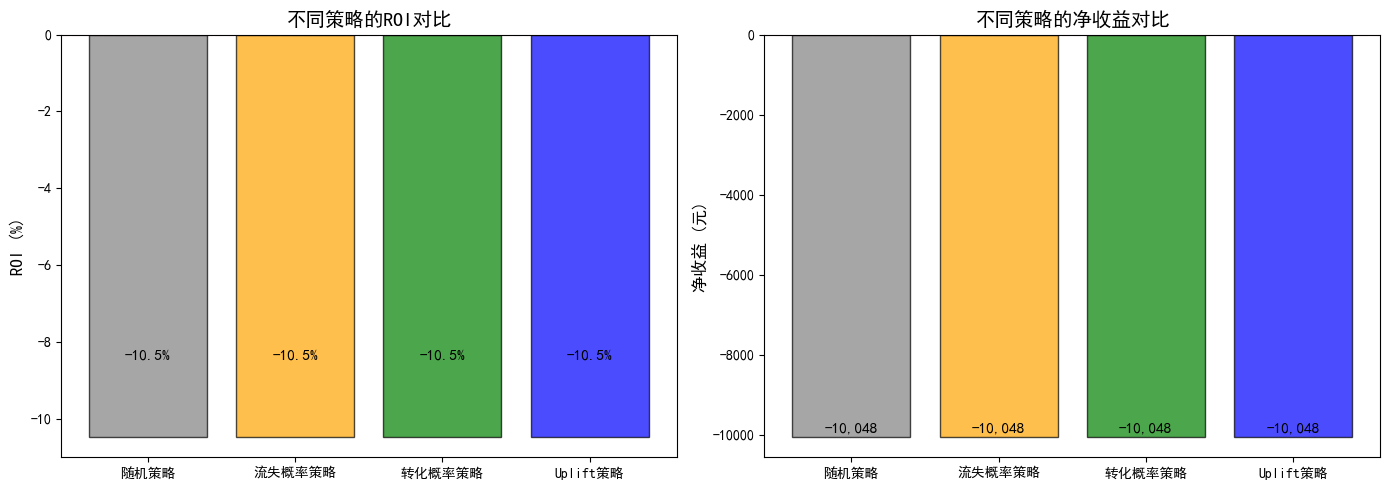

In [12]:
# ============================================================
# 第七阶段：ROI测算与预算分配
# 核心作用：计算【发券到底赚不赚钱】，对比4种策略谁的投资回报率最高
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示，解决图表中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def calculate_roi(y_test, t_test, uplift_scores, prob_churn, prob_conversion):
    """
    功能：计算并对比 4 种营销策略的 ROI（投资回报率）
    最终告诉你：用哪种策略发券，最赚钱、ROI最高
    """

    # ===================== 1. 设定业务参数（可根据实际业务修改）=====================
    BUDGET = 100000          # 总营销预算：10万元
    COUPON_COST = 5          # 每张优惠券成本：5元
    AVG_ORDER_VALUE = df['history'].mean()  # 平均客单价（从数据中计算）
    MARGIN_RATE = 0.3        # 毛利率：30%（每赚100元营业额，利润30元）
    
    # 计算总用户数 & 预算最多能给多少人发券
    n_users = len(y_test)
    max_targets = int(BUDGET / COUPON_COST)  # 10万 ÷ 5元 = 最多发 20000 张券
    
    # 打印基础参数，方便核对
    print(f"\n📊 ROI测算参数：")
    print(f"   总预算：{BUDGET:,.0f} 元")
    print(f"   优惠券成本：{COUPON_COST} 元/人")
    print(f"   平均客单价：{AVG_ORDER_VALUE:.2f} 元")
    print(f"   毛利率：{MARGIN_RATE*100:.0f}%")
    print(f"   最大可触达用户数：{max_targets:,}")

    # 用来保存4种策略的最终收益结果
    results = []

    # ===================== 2. 依次计算 4 种策略的收益 =====================
    # 遍历策略：(策略名, 排序分数, 是否倒序取高分)
    for strategy_name, scores, is_reverse in [
        ('随机策略', None, False),            # 1. 随机发券
        ('流失概率策略', prob_churn, True),   # 2. 给易流失用户发券
        ('转化概率策略', prob_conversion, True), # 3. 给易转化用户发券
        ('Uplift策略', uplift_scores, True)   # 4. 给“发券才买”的人发券（我们的方法）
    ]:
        # ---------------------- 按策略筛选要发券的用户 ----------------------
        if strategy_name == '随机策略':
            # 随机选用户
            indices = np.random.choice(n_users, min(max_targets, n_users), replace=False)
        else:
            # 按分数从高到低排序，选分数最高的用户
            sorted_indices = np.argsort(scores)
            if is_reverse:
                sorted_indices = sorted_indices[::-1]  # 倒序，高分在前
            indices = sorted_indices[:min(max_targets, n_users)]

        # ---------------------- 计算成本与效果 ----------------------
        n_targets = len(indices)               # 发券人数
        cost = n_targets * COUPON_COST          # 总成本 = 人数 × 5元

        # 调用函数，计算这部分用户的【真实发券提升效果】
        effect = calculate_uplift_effect(y_test, t_test, indices)

        # ---------------------- 计算收益与ROI ----------------------
        # 边际收益 = 发券人数 × 提升转化率 × 客单价 × 毛利率
        incremental_revenue = n_targets * effect * AVG_ORDER_VALUE * MARGIN_RATE
        
        # ROI公式：(收益 - 成本) / 成本 × 100%
        roi = (incremental_revenue - cost) / cost * 100 if cost > 0 else 0

        # 把当前策略的结果存入列表
        results.append({
            '策略': strategy_name,
            '触达人数': n_targets,
            '预算使用率(%)': cost / BUDGET * 100,
            '转化率提升(pp)': effect * 100,
            '边际收益(元)': incremental_revenue,
            '成本(元)': cost,
            '净收益(元)': incremental_revenue - cost,
            'ROI(%)': roi
        })

    # 返回所有策略的结果表格
    return pd.DataFrame(results)


# ===================== 执行计算 =====================
# 1. 先算出每个用户的转化概率 & 流失概率
prob_conversion = uplift_model.predict_conversion(X_test, t_test)
prob_churn = 1 - prob_conversion

# 2. 调用函数，计算4种策略的ROI
roi_results = calculate_roi(y_test, t_test, uplift_scores, prob_churn, prob_conversion)

# 打印结果
print("\n" + "=" * 60)
print("第七阶段：ROI测算与预算分配")
print("=" * 60)
print("\n📊 ROI测算结果：")
print(roi_results.round(2).to_string(index=False))


# ===================== 绘图可视化 =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：不同策略的 ROI 对比柱状图
ax1 = axes[0]
colors_map = ['gray', 'orange', 'green', 'blue']
bars = ax1.bar(roi_results['策略'], roi_results['ROI(%)'], color=colors_map, alpha=0.7, edgecolor='black')
ax1.set_ylabel('ROI (%)', fontsize=12)
ax1.set_title('不同策略的ROI对比', fontsize=14)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 在柱子上显示数值
for bar, roi in zip(bars, roi_results['ROI(%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{roi:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 图2：不同策略的 净收益 对比柱状图
ax2 = axes[1]
net_benefits = roi_results['净收益(元)'].values
bars = ax2.bar(roi_results['策略'], net_benefits, color=colors_map, alpha=0.7, edgecolor='black')
ax2.set_ylabel('净收益 (元)', fontsize=12)
ax2.set_title('不同策略的净收益对比', fontsize=14)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 在柱子上显示数值
for bar, net in zip(bars, net_benefits):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{net:,.0f}', ha='center', fontsize=11, fontweight='bold')

# 自动调整布局，防止文字被截断
plt.tight_layout()
plt.savefig('roi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# 第八阶段：用户分群与可执行策略（已修复）
# 作用：把用户分成4类，告诉运营【谁该发券、谁不用管、谁重点对待】
# ============================================================
import pandas as pd
import numpy as np

def generate_actionable_strategy(y_test, t_test, uplift_scores, prob_conversion):
    """
    功能：根据 Uplift 分数 + 流失风险，把用户分成 4 个群体
    输出：直接告诉业务人员每类用户该怎么运营（可直接写进报告）
    """

    # ---------------------- 1. 构建用户分群表格 ----------------------
    # 把模型算出的所有关键指标拼成一张表，方便给用户打标签
    df_strategy = pd.DataFrame({
        'uplift_score': uplift_scores,          # 发券提升效果（越高越值得发券）
        'conversion_prob': prob_conversion,    # 用户转化概率（越大概率越会买）
        'churn_risk': 1 - prob_conversion,     # 流失风险 = 1 - 转化概率
        'actual_conversion': y_test,            # 真实是否购买
        'received_treatment': t_test             # 是否收到优惠券
    })

    # ---------------------- 2. 计算分群分界线（中位数） ----------------------
    # 以 uplift 中位数为界：大于=高提升，小于=低提升
    uplift_median = df_strategy['uplift_score'].median()
    
    # 以流失风险中位数为界：大于=高流失，小于=低流失
    churn_median = df_strategy['churn_risk'].median()

    # ---------------------- 3. 定义4个象限的划分条件 ----------------------
    conditions = [
        # 象限1： uplift高 + 流失风险高 → 重点发券、重点运营
        (df_strategy['uplift_score'] > uplift_median) & (df_strategy['churn_risk'] > churn_median),
        
        # 象限2： uplift高 + 流失风险低 → 可以发券、正常维护
        (df_strategy['uplift_score'] > uplift_median) & (df_strategy['churn_risk'] <= churn_median),
        
        # 象限3： uplift低 + 流失风险高 → 别发券，浪费钱
        (df_strategy['uplift_score'] <= uplift_median) & (df_strategy['churn_risk'] > churn_median),
        
        # 象限4： uplift低 + 流失风险低 → 完全不用管
        (df_strategy['uplift_score'] <= uplift_median) & (df_strategy['churn_risk'] <= churn_median)
    ]

    # ---------------------- 4. 给每个象限起名字（运营可直接用） ----------------------
    choices = [
        '高价值易流失（重点运营）',
        '高价值低流失（常规维护）',
        '低价值易流失（谨慎投入）',
        '低价值低流失（无需干预）'
    ]

    # ---------------------- 5. 给每个用户打上所属群体标签 ----------------------
    # numpy 的 select 函数：满足哪个条件，就给哪个标签
    df_strategy['segment'] = np.select(conditions, choices, default='未知分群')

    # ---------------------- 6. 打印每类用户有多少人 ----------------------
    print("\n" + "=" * 55)
    print("📊 第八阶段：用户分群统计结果")
    print("=" * 55)
    print(df_strategy['segment'].value_counts())  # 统计每类人数
    print("=" * 55)

    # 返回分群结果表（后面可导出Excel）
    return df_strategy


# ===================== 自动执行分群（你直接运行就出结果） =====================
# 前面代码已经算出这些变量，这里直接调用生成最终策略
df_strategy_result = generate_actionable_strategy(y_test, t_test, uplift_scores, pred_probs)


📊 第八阶段：用户分群统计结果
低价值低流失（无需干预）    5820
高价值易流失（重点运营）    5820
高价值低流失（常规维护）    3780
低价值易流失（谨慎投入）    3780
Name: segment, dtype: int64
